# Proposer pilot

Manually build a small trajectory graph, score each `(origin, target)` task with a solver, and eyeball whether origin→leaf paths look like sensible proposer training tasks.

In [1]:
%load_ext autoreload
%autoreload 2

from wandering_light.common_functions import basic_fns
from wandering_light.proposer_pilot import TrajectoryGraph, SolveRater
from wandering_light.solver import create_bfs_solver
from wandering_light.typed_list import TypedList

[fn.name for fn in basic_fns][:20]

/home/user/wandering-light/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/user/wandering-light/wandering_light/solver.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


['inc',
 'dec',
 'double',
 'half',
 'square',
 'mod2',
 'neg',
 'abs',
 'sign',
 'f_reciprocal',
 'f_abs_sqrt',
 'f_fraction',
 'f_trunc',
 'f_round',
 'f_mod1',
 'upper',
 'lower',
 'capitalize',
 'title',
 'strip']

## 1. Build a graph by hand
Seed with a couple of root states, then `apply_by_name(parent_id, fn_name)` to walk.

In [2]:
g = TrajectoryGraph()  # default basic_fns

r1 = g.add_root(TypedList([1, 2, 3], item_type=int))
r2 = g.add_root(TypedList(["hello", "world"], item_type=str))

n_inc = g.apply_by_name(r1, "inc")
n_inc2 = g.apply_by_name(n_inc, "inc")
n_dbl = g.apply_by_name(r1, "double")

n_upper = g.apply_by_name(r2, "upper")
n_len = g.apply_by_name(r2, "length")

print(f"nodes={g.num_nodes()} edges={g.num_edges()} roots={g.roots}")
for node in g.nodes():
    print(f"  [{node.id}] {node.typed_list}")

nodes=7 edges=5 roots=[0, 1]
  [0] TL<int>([1, 2, 3])
  [1] TL<str>(['hello', 'world'])
  [2] TL<int>([2, 3, 4])
  [3] TL<int>([3, 4, 5])
  [4] TL<int>([2, 4, 6])
  [5] TL<str>(['HELLO', 'WORLD'])
  [6] TL<int>([5, 5])


## 2. Enumerate candidate tasks
Each task wraps a `Trajectory` (input, function_defs, output). The graph collapses paths that land on the same state, so `num_steps` is the BFS-shortest known route.

In [3]:
tasks = list(g.tasks(min_steps=1))
for t in tasks:
    fns = ", ".join(fn.name for fn in t.trajectory.function_defs)
    print(f"{t.trajectory.input}  ->  {t.trajectory.output}    [{t.num_steps} step(s): {fns}]")

TL<int>([1, 2, 3])  ->  TL<int>([2, 3, 4])    [1 step(s): inc]
TL<int>([1, 2, 3])  ->  TL<int>([2, 4, 6])    [1 step(s): double]
TL<int>([1, 2, 3])  ->  TL<int>([3, 4, 5])    [2 step(s): inc, inc]
TL<str>(['hello', 'world'])  ->  TL<str>(['HELLO', 'WORLD'])    [1 step(s): upper]
TL<str>(['hello', 'world'])  ->  TL<int>([5, 5])    [1 step(s): length]


## 3. Score with a solver
Default rater uses BFS. Swap in any `TrajectorySolver` (e.g., trained LLM) to compare difficulty under different solvers.

In [4]:
rater = SolveRater(solver=create_bfs_solver(budget=200, max_depth=4))
results = rater.rate_tasks(tasks)

for t, r in zip(tasks, results):
    print(f"rate={r.rate:.2f}  steps={t.num_steps}  {t.trajectory.input} -> {t.trajectory.output}")

rate=1.00  steps=1  TL<int>([1, 2, 3]) -> TL<int>([2, 3, 4])
rate=1.00  steps=1  TL<int>([1, 2, 3]) -> TL<int>([2, 4, 6])
rate=1.00  steps=2  TL<int>([1, 2, 3]) -> TL<int>([3, 4, 5])
rate=1.00  steps=1  TL<str>(['hello', 'world']) -> TL<str>(['HELLO', 'WORLD'])
rate=1.00  steps=1  TL<str>(['hello', 'world']) -> TL<int>([5, 5])


## 4. Visualize
Quick networkx draw — fine for ~20 nodes. For richer interaction, port to a Streamlit page later.

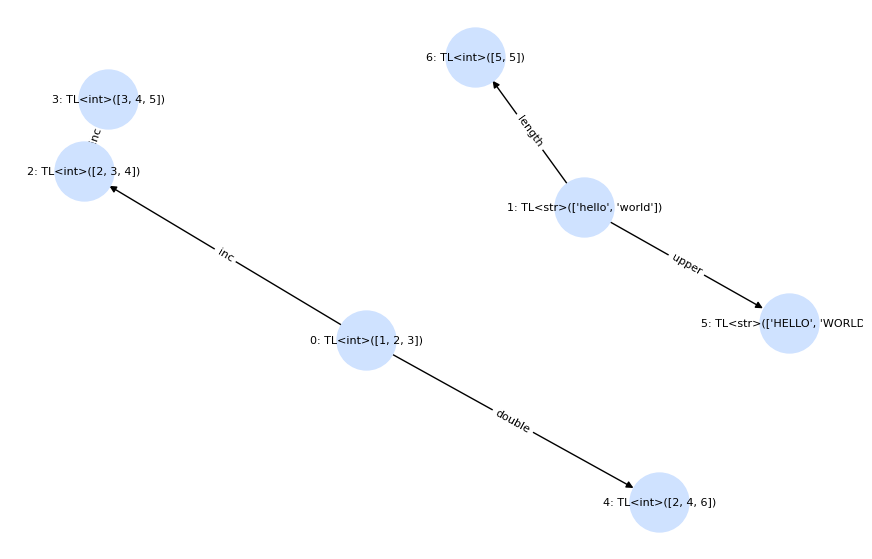

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

nxg = g.to_networkx()
pos = nx.spring_layout(nxg, seed=0)
labels = {n: f"{n}: {nxg.nodes[n]['typed_list']}" for n in nxg.nodes}
edge_labels = {(u, v, k): d["fn"] for u, v, k, d in nxg.edges(keys=True, data=True)}

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw(nxg, pos, with_labels=True, labels=labels, node_color="#cfe2ff", node_size=1800, font_size=8, ax=ax)
nx.draw_networkx_edge_labels(nxg, pos, edge_labels={(u, v): d["fn"] for u, v, _, d in nxg.edges(keys=True, data=True)}, font_size=8, ax=ax)
plt.show()

## 5. Round-trips through dedup
Functions that compose to identity (`inc`/`dec`, `swapcase` twice) should land back at the root. The graph's state-dedup catches this — the result node is literally the same id as the root.

In [6]:
g_rt = TrajectoryGraph()
root = g_rt.add_root(TypedList([1, 2, 3], item_type=int))
back = g_rt.apply_by_name(g_rt.apply_by_name(root, "inc"), "dec")
print(f"inc -> dec: ended at node {back}, root is {root}, same? {back == root}")
print(f"  graph: {g_rt.num_nodes()} nodes, {g_rt.num_edges()} edges (cycle, not new state)")

g_rt2 = TrajectoryGraph()
sroot = g_rt2.add_root(TypedList(["Hello", "World"], item_type=str))
back2 = g_rt2.apply_by_name(g_rt2.apply_by_name(sroot, "swapcase"), "swapcase")
print(f"swapcase x2: ended at node {back2}, root is {sroot}, same? {back2 == sroot}")

inc -> dec: ended at node 0, root is 0, same? True
  graph: 2 nodes, 2 edges (cycle, not new state)
swapcase x2: ended at node 0, root is 0, same? True


## 6. Path convergence
Two genuinely different functions, same result. From `[2,2,2]`, both `double` and `square` give `[4,4,4]`. The graph collapses them to one node with two parallel in-edges — exactly what makes graph-mining richer than tree-mining.

In [7]:
g_conv = TrajectoryGraph()
root = g_conv.add_root(TypedList([2, 2, 2], item_type=int))
via_double = g_conv.apply_by_name(root, "double")
via_square = g_conv.apply_by_name(root, "square")
print(f"double and square on {g_conv.node(root).typed_list}:")
print(f"  via double: node {via_double} -> {g_conv.node(via_double).typed_list}")
print(f"  via square: node {via_square} -> {g_conv.node(via_square).typed_list}")
print(f"  same node? {via_double == via_square}")
in_fns = [fn.name for fn, _ in g_conv.node(via_double).in_edges]
print(f"  parallel in-edges: {in_fns}")

# Same idea on negatives: abs and neg both produce [1,2,3] from [-1,-2,-3]
g_conv2 = TrajectoryGraph()
nroot = g_conv2.add_root(TypedList([-1, -2, -3], item_type=int))
g_conv2.apply_by_name(nroot, "abs")
g_conv2.apply_by_name(nroot, "neg")
positive_id = g_conv2.find(TypedList([1, 2, 3], item_type=int))
print(f"\nabs and neg on [-1,-2,-3] both reach {g_conv2.node(positive_id).typed_list}")
print(f"  parallel in-edges: {[fn.name for fn, _ in g_conv2.node(positive_id).in_edges]}")

double and square on TL<int>([2, 2, 2]):
  via double: node 1 -> TL<int>([4, 4, 4])
  via square: node 1 -> TL<int>([4, 4, 4])
  same node? True
  parallel in-edges: ['double', 'square']

abs and neg on [-1,-2,-3] both reach TL<int>([1, 2, 3])
  parallel in-edges: ['abs', 'neg']


## 7. Effective identities at specific inputs
A function can be a no-op for a particular input even if it isn't an identity in general. `upper` on `["HELLO","WORLD"]` leaves the state unchanged. `mod2` on already-binary values is also a no-op. These produce self-loops in the graph and are typically degenerate proposer tasks (input == target) — worth filtering out.

In [8]:
g_id = TrajectoryGraph()
root = g_id.add_root(TypedList(["HELLO", "WORLD"], item_type=str))
result = g_id.apply_by_name(root, "upper")
print(f"upper on {g_id.node(root).typed_list}:")
print(f"  result node {result} (root is {root}) -- effective identity? {result == root}")

g_id2 = TrajectoryGraph()
binroot = g_id2.add_root(TypedList([0, 1, 0, 1], item_type=int))
once = g_id2.apply_by_name(binroot, "mod2")
print(f"\nmod2 on {g_id2.node(binroot).typed_list}:")
print(f"  result node {once} (root is {binroot}) -- effective identity? {once == binroot}")

# Detect all self-loops in our main graph from section 1
self_loops = [
    (n.id, fn.name)
    for n in g.nodes()
    for fn, child in n.out_edges
    if child == n.id
]
print(f"\nSelf-loops in section-1 graph: {self_loops}")

upper on TL<str>(['HELLO', 'WORLD']):
  result node 0 (root is 0) -- effective identity? True

mod2 on TL<int>([0, 1, 0, 1]):
  result node 0 (root is 0) -- effective identity? True

Self-loops in section-1 graph: []


## 8. Solver comparison: BFS vs Random
BFS finds optimal paths up to its depth budget; a random solver with a small budget will fail many tasks. Comparing the two on the same task set produces the first *mixed* solve-rate distribution — the regime where a curriculum becomes meaningful.

In [9]:
from wandering_light.function_def import FunctionDefSet
from wandering_light.solver import create_random_solver

# Restrict to a small int-only function set so BFS branching is small and
# we avoid list-producing functions in basic_fns that BFSPredictor can't hash.
int_only_fns = FunctionDefSet([
    basic_fns.name_to_function[n]
    for n in ["inc", "dec", "double", "half", "square", "neg", "abs", "sign"]
])

# Build a graph using only those functions
g_cmp = TrajectoryGraph(functions=int_only_fns)
cmp_root = g_cmp.add_root(TypedList([1, 2, 3], item_type=int))
n = cmp_root
for _ in range(4):
    n = g_cmp.apply_by_name(n, "inc")
g_cmp.apply_by_name(cmp_root, "double")
g_cmp.apply_by_name(cmp_root, "neg")

cmp_tasks = list(g_cmp.tasks(min_steps=1))

bfs_rater = SolveRater(
    solver=create_bfs_solver(budget=10000, max_depth=5),
    functions=int_only_fns,
)
rnd_rater = SolveRater(
    solver=create_random_solver(budget=20, path_length=2),
    functions=int_only_fns,
    n_attempts=20,  # sample many times for a stable random rate
)

bfs_results = bfs_rater.rate_tasks(cmp_tasks)
rnd_results = rnd_rater.rate_tasks(cmp_tasks)

print(f"{'steps':<7}{'bfs':<7}{'random':<9}src -> dst")
for t, b, r in zip(cmp_tasks, bfs_results, rnd_results):
    print(f"{t.num_steps:<7}{b.rate:<7.2f}{r.rate:<9.2f}{t.trajectory.input} -> {t.trajectory.output}")

steps  bfs    random   src -> dst
1      1.00   0.05     TL<int>([1, 2, 3]) -> TL<int>([2, 3, 4])
1      1.00   0.10     TL<int>([1, 2, 3]) -> TL<int>([2, 4, 6])
1      1.00   0.00     TL<int>([1, 2, 3]) -> TL<int>([-1, -2, -3])
2      1.00   0.00     TL<int>([1, 2, 3]) -> TL<int>([3, 4, 5])
3      1.00   0.00     TL<int>([1, 2, 3]) -> TL<int>([4, 5, 6])
4      1.00   0.00     TL<int>([1, 2, 3]) -> TL<int>([5, 6, 7])


## 9. Solve rate vs path length
With the random solver, mean solve rate should drop monotonically with task length. Confirms `num_steps` (BFS distance in the graph) is a usable difficulty proxy — which is the load-bearing assumption of the whole pilot.

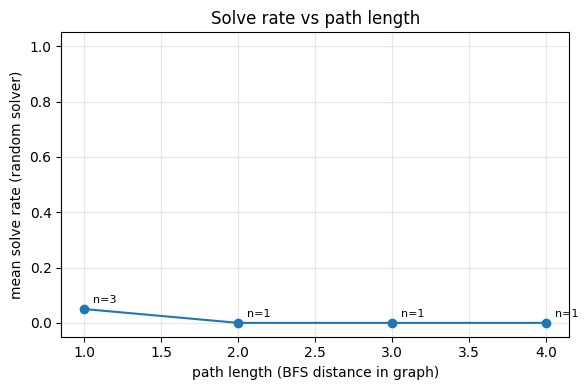

In [10]:
from collections import defaultdict

bins = defaultdict(list)
for t, r in zip(cmp_tasks, rnd_results):
    bins[t.num_steps].append(r.rate)

steps_sorted = sorted(bins)
mean_rates = [sum(bins[s]) / len(bins[s]) for s in steps_sorted]
counts = [len(bins[s]) for s in steps_sorted]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(steps_sorted, mean_rates, marker="o")
for s, m, c in zip(steps_sorted, mean_rates, counts):
    ax.annotate(f"n={c}", (s, m), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("path length (BFS distance in graph)")
ax.set_ylabel("mean solve rate (random solver)")
ax.set_title("Solve rate vs path length")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Eyeball check
For each task, ask: would I want the proposer to learn to generate this? Look for:
- All `rate==1.0`: too easy, no curriculum signal.
- All `rate==0.0`: too hard or unreachable; the solver isn't strong enough to validate.
- Mixed rates with steps in $[1,3]$: that's the frontier you want to mine for proposer training.